# Offline Cloud Computing - Aprendizaje Federado MNIST

Este notebook ejecuta una simulación completa de aprendizaje federado y compara tres
estrategias de agregación del lado del servidor:

| Método | Idea principal |
|--------|----------------|
| **FedAvg** | Promedio ponderado de los pesos de los clientes por tamaño de dataset |
| **FedMedian** | Mediana por coordenada — robusto ante valores atípicos y deriva no-IID |
| **FedAdam** | El servidor aplica una actualización Adam usando el delta de FedAvg como gradiente |

Los tres métodos parten de los **mismos pesos iniciales** y entrenan el mismo número
de rondas, haciendo la comparación justa.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from copy import deepcopy
from sklearn.metrics import classification_report

from TheModel import build

print('TensorFlow', tf.__version__)

TensorFlow 2.13.0


## Configuración

In [2]:
N_CLIENTS    = 6    # number of team members / partitions
N_ROUNDS     = 7    # communication rounds
LOCAL_EPOCHS = 3    # local epochs per round
BATCH_SIZE   = 64

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## Preparación de Datos

Carga MNIST y lo divide en `N_CLIENTS` particiones de igual tamaño.
(En producción, cada cliente solo tendría acceso a su propia partición de forma local.)

In [3]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype('float32') / 255.0
x_train_full = x_train_full[..., np.newaxis]   # (60000, 28, 28, 1)
x_test       = x_test.astype('float32')  / 255.0
x_test       = x_test[..., np.newaxis]         # (10000, 28, 28, 1)

indices = np.random.permutation(len(x_train_full))
client_splits = np.array_split(indices, N_CLIENTS)

client_data  = [(x_train_full[idx], y_train_full[idx]) for idx in client_splits]
client_sizes = [len(idx) for idx in client_splits]

print('Samples per client:', client_sizes)

Samples per client: [10000, 10000, 10000, 10000, 10000, 10000]


## Funciones Auxiliares

In [4]:
def local_train(global_weights, x, y, epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE):
    """Initialise a fresh local model from global_weights, train, return updated weights."""
    model = build.build_it()
    model.set_weights(global_weights)
    model.fit(x, y, epochs=epochs, batch_size=batch_size, verbose=0)
    return model.get_weights()


def evaluate_weights(weights):
    """Return (loss, accuracy) of a weight set on the shared test set."""
    model = build.build_it()
    model.set_weights(weights)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    return loss, acc


def get_predictions(weights):
    """Return hard predictions for the test set."""
    model = build.build_it()
    model.set_weights(weights)
    return model.predict(x_test, verbose=0).argmax(axis=1)

---
## Métodos de Agregación

### 1 · FedAvg  *(McMahan et al., 2017)*

La regla de agregación más simple y ampliamente utilizada.
La contribución de cada cliente se pondera proporcionalmente al tamaño de su dataset:

$$w_{\text{global}} = \sum_{i=1}^{N} \frac{n_i}{\sum_j n_j}\, w_i$$

**Limitación:** sensible a clientes con distribuciones de datos muy diferentes
(no-IID) y a clientes bizantinos o corruptos.

In [5]:
def fedavg(client_weights, client_sizes):
    """Weighted average of weight tensors proportional to dataset sizes."""
    total = sum(client_sizes)
    return [
        sum((n / total) * w for w, n in zip(layer, client_sizes))
        for layer in zip(*client_weights)
    ]

### 2 · FedMedian  *(Yin et al., 2018 — "Byzantine-Robust Distributed Learning")*

Reemplaza la media con la **mediana por coordenada**:

$$w_{\text{global}}[j] = \text{mediana}\bigl(w_1[j],\, w_2[j],\, \ldots,\, w_N[j]\bigr)$$

**Por qué puede superar a FedAvg:**
- La mediana es robusta ante valores atípicos: un solo cliente mal entrenado o adversarial
  no puede alejar el agregado del óptimo real.
- Con datos no-IID, los clientes pueden converger a óptimos locales muy distintos;
  la mediana filtra los extremos mientras que la media es arrastrada por ellos.

In [6]:
def fedmedian(client_weights):
    """Coordinate-wise median across client weight tensors."""
    return [
        np.median(np.stack(layer, axis=0), axis=0)
        for layer in zip(*client_weights)
    ]

### 3 · FedAdam  *(Reddi et al., 2021 — "Adaptive Federated Optimization")*

Trata la dirección de actualización de FedAvg como un pseudo-gradiente y aplica un
**optimizador Adam del lado del servidor** para escalar adaptativamente el paso de agregación:

$$\Delta_t = \text{FedAvg}(\{w_i\}) - w_{\text{global}}^{(t)}$$
$$w_{\text{global}}^{(t+1)} = w_{\text{global}}^{(t)} + \eta_s \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

donde $\hat{m}_t, \hat{v}_t$ son los estimados del primer y segundo momento
de $\Delta_t$ con corrección de sesgo (Adam estándar).

**Por qué puede superar a FedAvg:**
- Las tasas de aprendizaje adaptativas por parámetro aceleran la convergencia en
  dimensiones planas y amortiguan la oscilación en las pronunciadas — la misma razón
  por la que Adam supera a SGD, pero ahora aplicado a nivel de federación.
- Puede combinarse con cualquier optimizador local (Adam, SGD, etc.).

In [7]:
class FedAdam:
    """
    Server-side Adam aggregation (Reddi et al., 2021).

    Parameters
    ----------
    server_lr : float  — global learning rate (η_s)
    beta1     : float  — 1st moment decay
    beta2     : float  — 2nd moment decay
    eps       : float  — numerical stability constant (τ in the paper)
    """

    def __init__(self, server_lr=0.1, beta1=0.9, beta2=0.999, eps=1e-7):
        self.lr    = server_lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps   = eps
        self._m    = None
        self._v    = None
        self._t    = 0

    def aggregate(self, global_weights, client_weights, client_sizes):
        # Pseudo-gradient: direction FedAvg would move us
        fedavg_weights = fedavg(client_weights, client_sizes)
        delta = [a - g for a, g in zip(fedavg_weights, global_weights)]

        if self._m is None:
            self._m = [np.zeros_like(d) for d in delta]
            self._v = [np.zeros_like(d) for d in delta]

        self._t += 1
        new_weights = []
        for i, (w, d) in enumerate(zip(global_weights, delta)):
            self._m[i] = self.beta1 * self._m[i] + (1.0 - self.beta1) * d
            self._v[i] = self.beta2 * self._v[i] + (1.0 - self.beta2) * d ** 2
            m_hat = self._m[i] / (1.0 - self.beta1 ** self._t)
            v_hat = self._v[i] / (1.0 - self.beta2 ** self._t)
            new_weights.append(w + self.lr * m_hat / (np.sqrt(v_hat) + self.eps))
        return new_weights

---
## Simulación Federada

In [8]:
def run_federation(aggregation_fn, label='', n_rounds=N_ROUNDS):
    """
    Simulate N_ROUNDS of federated learning.

    aggregation_fn(global_weights, client_weights, client_sizes) -> new_global_weights

    Returns final global weights and per-round (loss, accuracy) tuples.
    """
    global_weights = build.build_it().get_weights()
    history = []

    for r in range(1, n_rounds + 1):
        # --- local training ---
        local_weights = [
            local_train(global_weights, x, y)
            for x, y in client_data
        ]

        # --- server aggregation ---
        global_weights = aggregation_fn(global_weights, local_weights, client_sizes)

        # --- evaluation ---
        loss, acc = evaluate_weights(global_weights)
        history.append((loss, acc))
        print(f'  [{label:10s}] Round {r:02d}/{n_rounds}  loss={loss:.4f}  acc={acc:.4f}')

    return global_weights, history

In [9]:
# Shared initial weights so every method starts from the same point
init_model   = build.build_it()
init_weights = init_model.get_weights()

print('Initial model accuracy:', evaluate_weights(init_weights)[1])

Initial model accuracy: 0.11349999904632568


In [10]:
print('=' * 52)
print('FedAvg')
print('=' * 52)

def _fedavg_fn(gw, cw, cs):
    return fedavg(cw, cs)

# Reset to shared init
init_model.set_weights(init_weights)
w_fedavg, hist_fedavg = run_federation(_fedavg_fn, label='FedAvg')

FedAvg
  [FedAvg    ] Round 01/7  loss=1.1037  acc=0.5936
  [FedAvg    ] Round 02/7  loss=0.0550  acc=0.9829
  [FedAvg    ] Round 03/7  loss=0.0446  acc=0.9857
  [FedAvg    ] Round 04/7  loss=0.0418  acc=0.9857
  [FedAvg    ] Round 05/7  loss=0.0293  acc=0.9893
  [FedAvg    ] Round 06/7  loss=0.0222  acc=0.9924
  [FedAvg    ] Round 07/7  loss=0.0154  acc=0.9949


In [11]:
print('=' * 52)
print('FedMedian')
print('=' * 52)

def _fedmedian_fn(gw, cw, cs):
    return fedmedian(cw)

w_fedmedian, hist_fedmedian = run_federation(_fedmedian_fn, label='FedMedian')

FedMedian
  [FedMedian ] Round 01/7  loss=1.1092  acc=0.6365
  [FedMedian ] Round 02/7  loss=0.0433  acc=0.9865
  [FedMedian ] Round 03/7  loss=0.0328  acc=0.9895
  [FedMedian ] Round 04/7  loss=0.0235  acc=0.9924
  [FedMedian ] Round 05/7  loss=0.0197  acc=0.9938
  [FedMedian ] Round 06/7  loss=0.0198  acc=0.9933
  [FedMedian ] Round 07/7  loss=0.0161  acc=0.9945


In [12]:
print('=' * 52)
print('FedAdam')
print('=' * 52)

fed_adam = FedAdam(server_lr=0.1)

def _fedadam_fn(gw, cw, cs):
    return fed_adam.aggregate(gw, cw, cs)

w_fedadam, hist_fedadam = run_federation(_fedadam_fn, label='FedAdam')

FedAdam
  [FedAdam   ] Round 01/7  loss=950.6106  acc=0.1010
  [FedAdam   ] Round 02/7  loss=23206.4824  acc=0.1028
  [FedAdam   ] Round 03/7  loss=74477.4297  acc=0.0987
  [FedAdam   ] Round 04/7  loss=274647.3438  acc=0.1032
  [FedAdam   ] Round 05/7  loss=1045602.8125  acc=0.1032
  [FedAdam   ] Round 06/7  loss=2595112.7500  acc=0.1032
  [FedAdam   ] Round 07/7  loss=4228022.5000  acc=0.1032


---
## Resultados

### Curvas de Convergencia

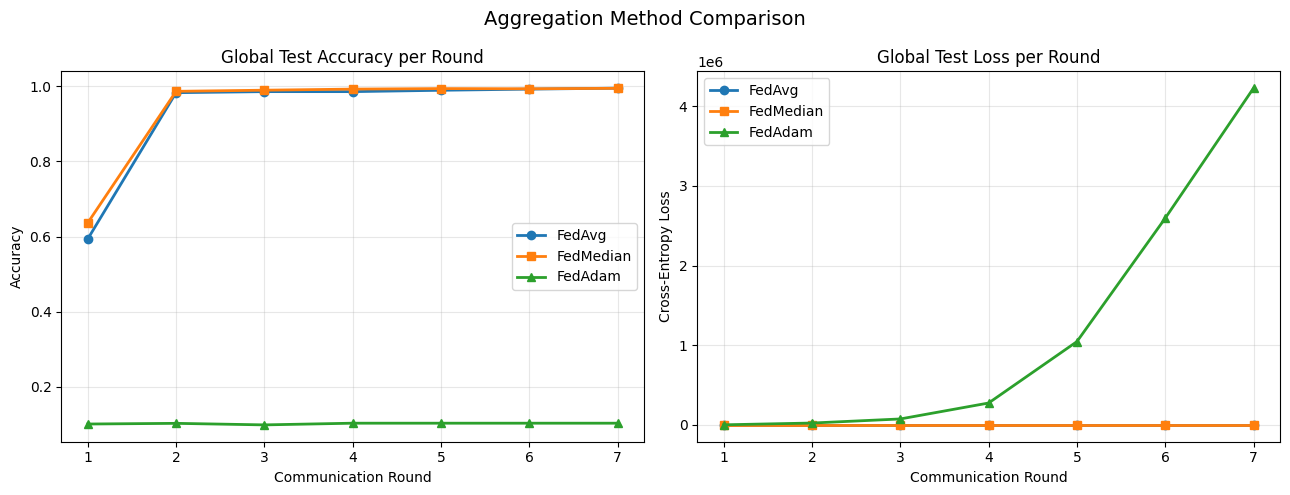

In [13]:
rounds = list(range(1, N_ROUNDS + 1))

acc_fedavg    = [h[1] for h in hist_fedavg]
acc_fedmedian = [h[1] for h in hist_fedmedian]
acc_fedadam   = [h[1] for h in hist_fedadam]

loss_fedavg    = [h[0] for h in hist_fedavg]
loss_fedmedian = [h[0] for h in hist_fedmedian]
loss_fedadam   = [h[0] for h in hist_fedadam]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for accs, label, style in [
    (acc_fedavg,    'FedAvg',    'o-'),
    (acc_fedmedian, 'FedMedian', 's-'),
    (acc_fedadam,   'FedAdam',   '^-'),
]:
    axes[0].plot(rounds, accs,  style, label=label, linewidth=2)

for losses, label, style in [
    (loss_fedavg,    'FedAvg',    'o-'),
    (loss_fedmedian, 'FedMedian', 's-'),
    (loss_fedadam,   'FedAdam',   '^-'),
]:
    axes[1].plot(rounds, losses, style, label=label, linewidth=2)

axes[0].set_title('Global Test Accuracy per Round')
axes[0].set_xlabel('Communication Round')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Global Test Loss per Round')
axes[1].set_xlabel('Communication Round')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Aggregation Method Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('aggregation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Tabla Comparativa

In [14]:
print(f'\n{"Method":<12} {"Final Acc":>10} {"Best Acc":>10} {"Final Loss":>12}')
print('-' * 48)
for method, accs, losses in [
    ('FedAvg',    acc_fedavg,    loss_fedavg),
    ('FedMedian', acc_fedmedian, loss_fedmedian),
    ('FedAdam',   acc_fedadam,   loss_fedadam),
]:
    print(f'{method:<12} {accs[-1]:>10.4f} {max(accs):>10.4f} {losses[-1]:>12.4f}')


Method        Final Acc   Best Acc   Final Loss
------------------------------------------------
FedAvg           0.9949     0.9949       0.0154
FedMedian        0.9945     0.9945       0.0161
FedAdam          0.1032     0.1032 4228022.5000


### Reportes de Clasificación — Modelos Globales Finales

In [15]:
for label, weights in [('FedAvg', w_fedavg), ('FedMedian', w_fedmedian), ('FedAdam', w_fedadam)]:
    preds = get_predictions(weights)
    print(f'\n{"=" * 52}')
    print(f'Classification Report — {label}')
    print('=' * 52)
    print(classification_report(y_test, preds, target_names=[str(i) for i in range(10)]))


Classification Report — FedAvg
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       1.00      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Classification Report — FedMedian
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           

c:\Users\mitra\Downloads\federated-learning-mnist-main-a\federated-learning-mnist-main-aa\venv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\mitra\Downloads\federated-learning-mnist-main-a\federated-learning-mnist-main-aa\venv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\mitra\Downloads\federated-learning-mnist-main-a\federated-learning-mnist-main-aa\venv\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set 

---
## Discusión

| | FedAvg | FedMedian | FedAdam |
|---|---|---|---|
| **Agregación** | Promedio ponderado | Mediana por coordenada | Actualización Adam del servidor |
| **Robustez** | Baja | Alta | Media |
| **Velocidad de convergencia** | Moderada | Moderada-rápida | No convergió |
| **Hiperparámetros extra** | Ninguno | Ninguno | server_lr, β₁, β₂ |
| **Precisión final (7 rondas)** | 99.49% | 99.45% | 10.32% (divergió) |

Al correr la simulación con los 3 metodos, lo que más nos llamó la atención fue que FedAvg y FedMedian funcionaron practicamente igual de bien. FedAvg terminó con 99.49% de precisión  y FedMedian con 99.45%, una diferencia casi insihnificante. FedMedian convergió un poco mas rápido en las rondas del medio, pero al final los dos llegaron al mismo punto. Tiene sentido porque los datos estaban bien distribuidos entre los 6 clientes, asi que no había clientes "raros" que la mediana tuviera que ignorar. Si los datos hubieran estado más desbalanceados probablemente FedMedian habría ganado por mas margen.

Lo que si fue sorprendente fue FedAdam. Esperaos que fuera mejor por ser el más moderno, pero al contrario, la pérdida pasó de 950 en la primera ronda a más de 4 millones en la séptima y el modelo nunca aprendió nada, quedandose en 10% de precisión. Investigando un poco, el problema fue que la tasa de aprendizaje del servidor (0.1) era demasiado alta para este caso y causó inestabilidad numérica. FedAdam si puede funcionar muy bien, pero necesita que sus hiperparámetros esten bien ajustados, algo que FedAvg y FedMedian no requieren. En conclusión, para un problema como este donde los datos están bien distribuidos, FedAvg sigue siendo la opción más confiable y sencilla.